In [103]:

from dotenv import load_dotenv
import sqlite3
from langchain_core.tools import tool
import os
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from typing import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, AIMessage
load_dotenv()

True

##### Initialize LLM

In [104]:
llm = ChatOpenAI(
    model = "gpt-4o-mini",
    temperature = 0,
    api_key = os.getenv("OPENAI_API_KEY")
)

##### Initialize State and Schema

In [105]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    query: str
    guardrail1_status: Literal["Fail", "Success", None]
    guardrail2_status: Literal["Fail", "Success", None]
    sql_query: str
    output: str

In [106]:
class guardrial(BaseModel):
    guardrial_status: Literal["Fail", "Success"]
llm_with_guardrail = llm.with_structured_output(guardrial)

In [107]:
class SQLQuery(BaseModel):
    sql: str = Field(description= "SQL query which can directly run without any preprocessing")
llm_for_sql = llm.with_structured_output(SQLQuery)

#### Tool

In [108]:
@tool
def fetch_tables() -> dict:
    '''
        This returns all table names with short description of what data
        it contains.
    '''
    tables = {
        "categories": "Product categories like Mountain Bikes, Road Bikes, or Cruisers used to classify inventory.",
        "brands": "Bicycle manufacturers and brand names (e.g., Trek, Electra, Surly) available in the catalog.",
        "products": "The main bike catalog detailing model names, prices, brand/category links, and model years.",
        "customers": "Customer profiles containing full names, phone numbers, emails, and geographic/billing addresses.",
        "stores": "Physical retail store locations, including contact information and location addresses where inventory is held.",
        "staffs": "Employee profiles detailing job roles, store assignments, active employment status, and manager hierarchies.",
        "orders": "High-level transaction records tracking order dates, required dates, shipping statuses, customers, and assigned staff.",
        "order_items": "Granular transaction line-items detailing products sold, ordered quantities, list prices, and item-specific discounts.",
        "stocks": "Real-time inventory levels mapping the exact quantity available for each product at each specific physical store location."
    }
    
    return tables

In [109]:
@tool
def fetch_schema(tables: list) -> dict:
    '''
        This returns schema for the list of table names provided as input.
        This returns a dictionary, where key is the table name and value
        is its schema description
    '''
    table_schemas = {
            "categories": {
                "description": "Product categories used to classify inventory profiles.",
                "primary_key": "category_id",
                "foreign_keys": [],
                "columns": {
                    "category_id": "INTEGER. Primary key. Unique category identifier.",
                    "category_name": "TEXT. The descriptive name of the category (e.g., 'Mountain Bikes', 'Road Bikes', 'Cruisers')."
                }
            },
            "brands": {
                "description": "Bicycle manufacturers and brand names available in the catalog.",
                "primary_key": "brand_id",
                "foreign_keys": [],
                "columns": {
                    "brand_id": "INTEGER. Primary key. Unique brand identifier.",
                    "brand_name": "TEXT. The official manufacturer name (e.g., 'Trek', 'Electra', 'Surly', 'Sun Bicycles')."
                }
            },
            "products": {
                "description": "The master bike catalog detailing individual bicycle models, manufacturing years, and MSRP baseline prices.",
                "primary_key": "product_id",
                "foreign_keys": [
                    "brand_id references brands(brand_id)",
                    "category_id references categories(category_id)"
                ],
                "columns": {
                    "product_id": "INTEGER. Primary key. Unique bike item code identifier.",
                    "product_name": "TEXT. The full consumer name of the bicycle model.",
                    "brand_id": "INTEGER. Foreign key. Identifies the bike manufacturer; links directly to brands.brand_id.",
                    "category_id": "INTEGER. Foreign key. Identifies the bike style class; links directly to categories.category_id.",
                    "model_year": "INTEGER. The manufacturing and release year of the bicycle model (formatted as YYYY).",
                    "list_price": "DECIMAL(10,2). Base MSRP retail price before any point-of-sale discounts."
                }
            },
            "customers": {
                "description": "Consumer client profile directory containing contact data and geographic breakdown.",
                "primary_key": "customer_id",
                "foreign_keys": [],
                "columns": {
                    "customer_id": "INTEGER. Primary key. Unique customer account identifier.",
                    "first_name": "TEXT. Customer's given name.",
                    "last_name": "TEXT. Customer's family surname.",
                    "phone": "TEXT. Customer contact number. Note: Can be NULL if not provided.",
                    "email": "TEXT. Customer electronic mail address.",
                    "street": "TEXT. Local residential or billing street address text line.",
                    "city": "TEXT. City where the customer lives (useful for regional sales grouping).",
                    "state": "TEXT. Two-letter state code abbreviation (e.g., 'NY', 'CA', 'TX') where customer resides.",
                    "zip_code": "TEXT. Local postal mail sorting numeric tracking text code."
                }
            },
            "stores": {
                "description": "Physical retail outlet locations handling stock storage and local fulfillment transaction points.",
                "primary_key": "store_id",
                "foreign_keys": [],
                "columns": {
                    "store_id": "INTEGER. Primary key. Unique showroom retail store branch identifier.",
                    "store_name": "TEXT. Human name of the physical location (e.g., 'Santa Cruz Bikes', 'Baldwin Bikes').",
                    "phone": "TEXT. Direct telephone contact line for the store branch location.",
                    "email": "TEXT. Store customer service shared inbox address line.",
                    "street": "TEXT. Showroom street location text descriptor.",
                    "city": "TEXT. City where this specific shop branch handles daily sales operations.",
                    "state": "TEXT. State branch operations location zone code.",
                    "zip_code": "TEXT. Showroom local area mailing address zip sequence."
                }
            },
            "staffs": {
                "description": "Employee profile repository tracking corporate organizational charts, managers, active workers, and job placements.",
                "primary_key": "staff_id",
                "foreign_keys": [
                    "store_id references stores(store_id)",
                    "manager_id references staffs(staff_id)"
                ],
                "columns": {
                    "staff_id": "INTEGER. Primary key. Unique corporate worker internal identity code.",
                    "first_name": "TEXT. Employee's given front name.",
                    "last_name": "TEXT. Employee's family group surname code.",
                    "email": "TEXT. Business communication staff mailbox address route.",
                    "phone": "TEXT. Direct corporate mobile assignment extension line.",
                    "active": "INTEGER. Status flag: 1 = Currently Employed/Active; 0 = Inactive/Terminated. Filter out 0 for team headcount.",
                    "store_id": "INTEGER. Foreign key. Identifies which primary brick-and-mortar outlet this employee is assigned to; links to stores.store_id.",
                    "manager_id": "INTEGER. Foreign key. Self-referencing link to another staff member's staff_id who is this person's supervisor. Root bosses have NULL here."
                }
            },
            "orders": {
                "description": "High-level sale transaction headers tracking execution timeline phases, order placement times, and routing stakeholders.",
                "primary_key": "order_id",
                "foreign_keys": [
                    "customer_id references customers(customer_id)",
                    "store_id references stores(store_id)",
                    "staff_id references staffs(staff_id)"
                ],
                "columns": {
                    "order_id": "INTEGER. Primary key. Unique checkout instance receipt tracking identifier.",
                    "customer_id": "INTEGER. Foreign key. Identifies the purchasing consumer client; links to customers.customer_id.",
                    "order_status": "INTEGER. CRITICAL LOOKUP FLAG. State phases: 1 = Pending; 2 = Processing; 3 = Rejected; 4 = Shipped. Use 4 for finalized metrics.",
                    "order_date": "TEXT. The calendar creation date when the checkout event initiated (formatted as YYYY-MM-DD).",
                    "required_date": "TEXT. Target delivery deadline milestone scheduled date window (formatted as YYYY-MM-DD).",
                    "shipped_date": "TEXT. Finalized dispatch shipping date from storage hub (formatted as YYYY-MM-DD). Can be NULL if order status is not 4.",
                    "store_id": "INTEGER. Foreign key. Registers which physical branch closed this invoice transaction; links to stores.store_id.",
                    "staff_id": "INTEGER. Foreign key. Tracks which sales representative closed this basket; links to staffs.staff_id."
                }
            },
            "order_items": {
                "description": "Granular point-of-sale line item entries. Use this table for calculating finance metrics like revenue, unit margins, and absolute item volumes.",
                "primary_key": "(order_id, item_id) - Composite Key",
                "foreign_keys": [
                    "order_id references orders(order_id)",
                    "product_id references products(product_id)"
                ],
                "columns": {
                    "order_id": "INTEGER. Primary key component. Foreign key connection tracing back to the master container; links to orders.order_id.",
                    "item_id": "INTEGER. Primary key component. Sequential line index counter number inside a single cart instance (e.g., item 1, item 2).",
                    "product_id": "INTEGER. Foreign key. Tracks the precise bicycle model purchased; links to products.product_id.",
                    "quantity": "INTEGER. Total number of volume units bought for this item.",
                    "list_price": "DECIMAL(10,2). Base selling price recorded at the time of purchase execution.",
                    "discount": "DECIMAL(4,2). Absolute percentage deduction modifier written as a floating decimal fraction (e.g., 0.05 means 5% off, 0.20 means 20% off). CRITICAL MATHEMATICAL FORMULA FOR COMPUTING REVENUE METRICS: SUM(quantity * list_price * (1 - discount))"
                }
            },
            "stocks": {
                "description": "Real-time physical inventory matrix log evaluating localized stock level capacities across separate network retail nodes.",
                "primary_key": "(store_id, product_id) - Composite Key",
                "foreign_keys": [
                    "store_id references stores(store_id)",
                    "product_id references products(product_id)"
                ],
                "columns": {
                    "store_id": "INTEGER. Primary key component. Foreign key tracking where the physical items reside; links to stores.store_id.",
                    "product_id": "INTEGER. Primary key component. Foreign key tracking what physical asset is being stacked; links to products.product_id.",
                    "quantity": "INTEGER. Total volume capacity count currently remaining sitting on the shelf inside that store floor location."
                }
            }
        }

    output_schema = {}
    for table in tables:
        output_schema[table] = table_schemas[table].copy()
    
    return output_schema

In [110]:
@tool
def execute_query(query:str) -> str:
    '''
        Execute SQL query and return results
    '''
    result = []
    result_str = ""
    conn = sqlite3.connect("bike_store.db")

    cursor = conn.cursor()

    response = cursor.execute(query)

    columns = [col[0] for col in cursor.description]
    result_str =result_str+ "\n".join(columns)
    result.append(columns)
    for i in response:
        result.append(i)
        result_str =result_str+ "\n".join(map(str, i))

    
    conn.close()
    return result_str

In [111]:
fetch_schema_tools = [fetch_tables, fetch_schema]
tools_with_name_schema = {"fetch_tables": fetch_tables, "fetch_schema": fetch_schema}
fetch_schema_llm = llm.bind_tools(fetch_schema_tools)

In [112]:
execute_query_llm = llm.bind_tools([execute_query])
tools_with_name_execute = {"execute_query": execute_query}

##### Nodes

In [113]:
def query_guardrails(state:State)-> State:
    '''
    Define guardrails for input query.
    Check if this query is safe to proceed with.
    It should be read only.
    '''
    # prompt = ("human",'''
    #     Check if the query asked by the user only performs a read only operation, if it needs to perform operation like writing, creating, editing or deleting something, return Fail else return Success
    # '''.strip())
    # state["messages"].append(prompt)
    
    # response = llm_with_guardrail.invoke(state["messages"]).guardrial_status
    # state["guardrail1_status"] = response
    
    state["messages"] = [AIMessage(content = f"{state["guardrail1_status"]} query Guardrail1")]
    return state    

In [114]:
def guardrail1_router(state:State)-> str:
    if(state["guardrail1_status"] == "Fail"):
        return END
    else:
        return "get_schema"

In [115]:
def get_schema(state:State)-> State:
    '''
    Use tools to get table schema:
    Tool 1: Get table names available with a small summary
    Tool 2: Get table schema needed to answer the query
    '''
    prompt = ("human",
              '''
                Analyze the input query and identify the tables and their schema needed to fulfill the request. When you are done, just say that you have the schema required to process the query.
              '''.strip())
    state["messages"].append(prompt)
    
    response = fetch_schema_llm.invoke(state["messages"])
    state["messages"] = [response]
    return state 

In [116]:
def schema_tool_router(state:State)-> str:
    last_message = state["messages"][-1]
    
    if(last_message.tool_calls):
        return "schema_tool_node"
    else:
        return "generate_sql_query"

In [117]:
def schema_tool_node(state:State)-> State:
    message = state["messages"][-1]
    if(message.tool_calls):
        for tool_call in message.tool_calls:
            response = tools_with_name_schema[tool_call["name"]].invoke(tool_call["args"])
            state["messages"].append(
                ToolMessage(content = response, tool_call_id= tool_call["id"])
            )
    return state

In [118]:
def generate_sql_query(state:State)-> State:
    '''
        Generate sql query using table schea and input query prompt
    '''
    prompt = HumanMessage(content = '''
                          Generate an sql query to fulfil the input query. Utilize the table schema generated before.
                          '''.strip())
    state["messages"].append(prompt)
    
    response = llm_for_sql.invoke(state["messages"])
    state["messages"] = response.sql
    state["sql_query"] = response.sql
    return state

In [119]:
def sql_query_guardrails(state:State)-> State:
    '''
        Check if the query is safe to use
        1. Check if its read only
        2. Check if its not deleting or updating anything
    '''
    state["messages"] = "passed guardrail 2"
    return state

In [120]:
def guardrail2_router(state: State)-> str:
    if (state["guardrail2_status"] == "Fail"):
        return "generate_sql_query"
    else:
        return "execute_sql_query"

In [121]:
def execute_sql_query(state:State)-> State:
    prompt = HumanMessage(content = f'''
    Execute this SQL query and get results. SQL Query: {state["sql_query"]}.
    '''.strip())
    state["messages"].append(prompt)
    results = execute_query_llm.invoke(state["messages"])
    state["messages"].append(results)
    
    if(results.tool_calls):
        for tool in results.tool_calls:
            tool_output = tools_with_name_execute[tool["name"]].invoke(tool["args"])
            state["messages"].append(ToolMessage(content = tool_output, tool_call_id = tool["id"]))
    else:
        state["messages"].append(f"Error! Query Did not get executed.")
    return state

In [122]:
def validate_results(state:State)-> State:
    '''
        Check if generated results are the one that was originally asked
    '''
    state["messages"] = "Validated results"
    return state

In [123]:
def generate_analysis(state:State)-> State:
    '''
        Use visualization and other tools to generate analysis
    '''
    prompt = HumanMessage(content = f'''
    Provide an answer to this query: {state["query"]}
    '''.strip())
    state["messages"].append(prompt)
    
    result = llm.invoke(state["messages"])
    state["messages"] = result
    state["output"] = result
    return state

##### Graph

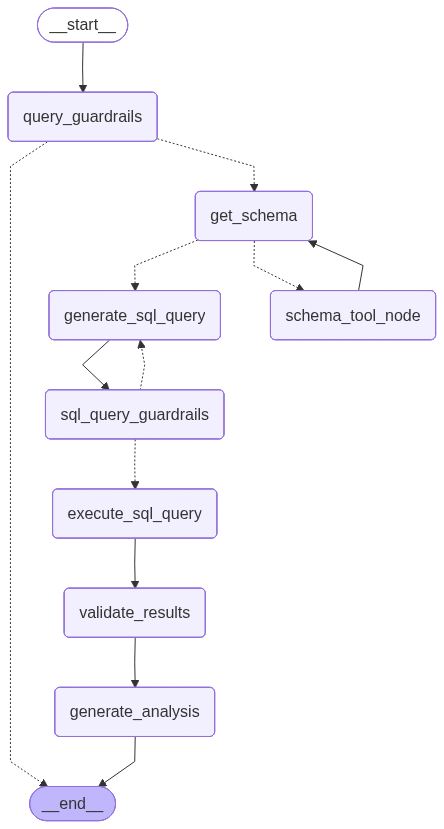

In [124]:
graph = StateGraph(State)

graph.add_node("query_guardrails", query_guardrails)
graph.add_node("get_schema", get_schema)
graph.add_node("schema_tool_node", schema_tool_node)
graph.add_node("generate_sql_query", generate_sql_query)
graph.add_node("sql_query_guardrails", sql_query_guardrails)
graph.add_node("execute_sql_query", execute_sql_query)
graph.add_node("validate_results", validate_results)
graph.add_node("generate_analysis", generate_analysis)


graph.add_edge(START, "query_guardrails")
graph.add_conditional_edges("query_guardrails", guardrail1_router, {END:END, "get_schema": "get_schema"})
graph.add_conditional_edges("get_schema", schema_tool_router, {"schema_tool_node": "schema_tool_node", "generate_sql_query": "generate_sql_query"})
graph.add_edge("schema_tool_node", "get_schema")
# graph.add_edge("get_schema", "generate_sql_query")
graph.add_edge("generate_sql_query", "sql_query_guardrails")
graph.add_conditional_edges("sql_query_guardrails", guardrail2_router, {"generate_sql_query": "generate_sql_query", "execute_sql_query": "execute_sql_query"})
graph.add_edge("execute_sql_query", "validate_results")
graph.add_edge("validate_results", "generate_analysis")
graph.add_edge("generate_analysis", END)



compiled_graph = graph.compile()
compiled_graph


In [125]:
query = ''' What are the top 3 best-selling bike brands based on total revenue,
and which store sold the most of them?'''
# query = ''' Delete orders table '''

In [126]:
inputs = {
    "messages": [
        ("system", '''You are a helpful data analyst who can analyze the data based on a query.
                      '''.strip()),
        ("human", f'''
                     Analysis to perform, Query: {query}
                     '''.strip())
    ],
    "query": f"{query}",
    "guardrail1_status": "Success",
    "guardrail2_status": None,
    "output": "",
    "sql_query": ""
}

In [127]:
for event in compiled_graph.stream(
    inputs,
    stream_mode = "values"
):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Analysis to perform, Query:  What are the top 3 best-selling bike brands based on total revenue,
and which store sold the most of them?
================================== Ai Message ==================================

Success query Guardrail1
================================== Ai Message ==================================
Tool Calls:
  fetch_tables (call_qIQAG4Xjw5nKGDF9BK1qy0Ho)
 Call ID: call_qIQAG4Xjw5nKGDF9BK1qy0Ho
  Args:
================================= Tool Message =================================

{'categories': 'Product categories like Mountain Bikes, Road Bikes, or Cruisers used to classify inventory.', 'brands': 'Bicycle manufacturers and brand names (e.g., Trek, Electra, Surly) available in the catalog.', 'products': 'The main bike catalog detailing model names, prices, brand/category links, and model years.', 'customers': 'Customer profiles containing full names, phone numbers, emails, and 

In [130]:
print(event["output"].content)

The top 3 best-selling bike brands based on total revenue are:

1. **Brand:** Trek
   - **Total Revenue:** $3,124,284.78
   - **Store:** Baldwin Bikes

2. **Brand:** Trek
   - **Total Revenue:** $925,814.53
   - **Store:** Santa Cruz Bikes

3. **Brand:** Electra
   - **Total Revenue:** $808,762.05
   - **Store:** Baldwin Bikes

Trek is the leading brand in terms of total revenue, with Baldwin Bikes being the store that sold the most of them.
